In [1]:
!pip install -q sentence-transformers scikit-learn matplotlib pandas

In [2]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully!


In [3]:
sentence = "I enjoy learning about healthy nutrition."

embedding = model.encode(sentence)

print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Sentence: I enjoy learning about healthy nutrition.
Embedding shape: (384,)
First 10 values: [ 0.01461492 -0.03103057  0.0054383   0.0909768   0.03175502 -0.00058241
  0.05339564 -0.00843692 -0.02637261 -0.00353674]


In [4]:
sentences = [
    "I love eating fresh fruits",
    "Vegetables are important for a healthy diet",
    "The football match was exciting",
    "Healthy meals provide essential nutrients",
    "The basketball team won the game"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 5
Embedding matrix shape: (5, 384)


In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(
    similarity_matrix,
    index=sentences,
    columns=sentences
)

df.round(2)

,I love eating fresh fruits,Vegetables are important for a healthy diet,The football match was exciting,Healthy meals provide essential nutrients,The basketball team won the game
I love eating fresh fruits,1.00,0.44,0.13,0.40,0.09
Vegetables are important for a healthy diet,0.44,1.00,-0.06,0.65,0.01
The football match was exciting,0.13,-0.06,1.00,0.01,0.32
Healthy meals provide essential nutrients,0.40,0.65,0.01,1.00,0.06
The basketball team won the game,0.09,0.01,0.32,0.06,1.00


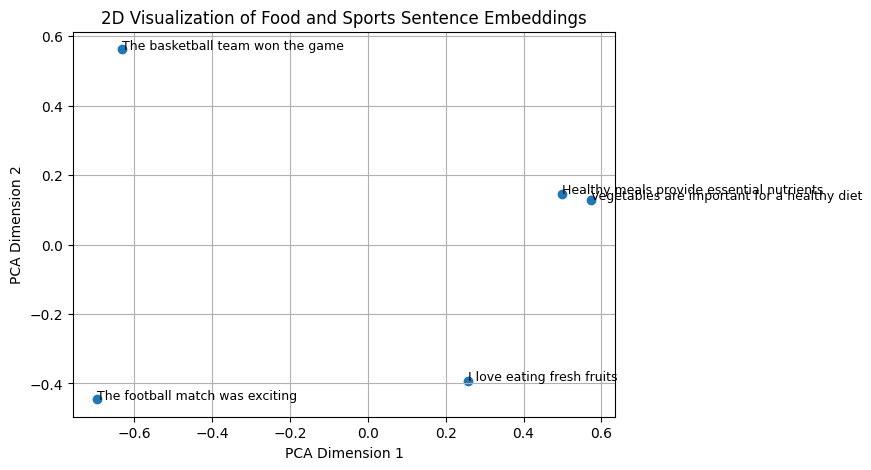

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))

plt.scatter(
    reduced[:, 0],
    reduced[:, 1]
)

for i, sent in enumerate(sentences):
    plt.annotate(
        sent,
        (reduced[i, 0], reduced[i, 1]),
        fontsize=9
    )

plt.title("2D Visualization of Food and Sports Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

In [7]:
# Our small "document" database

documents = [
    "Fruits and vegetables provide important vitamins and minerals.",
    "The weather today is sunny and warm.",
    "A balanced diet contains carbohydrates, proteins, fats, vitamins, and minerals.",
    "I enjoy playing football with my friends.",
    "Drinking enough water is important for good health.",
    "Protein helps the body build and repair muscles."
]

In [8]:
# Encode all documents once

doc_embeddings = model.encode(documents)

In [9]:
def semantic_search(query, top_k=2):

    query_embedding = model.encode([query])

    scores = cosine_similarity(
        query_embedding,
        doc_embeddings
    )[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")

    for idx in ranked_idx:
        print(
            f"Score: {scores[idx]:.3f} | {documents[idx]}"
        )

In [10]:
semantic_search(
    "What foods provide vitamins and minerals?"
)

Query: What foods provide vitamins and minerals?

Score: 0.741 | Fruits and vegetables provide important vitamins and minerals.
Score: 0.538 | A balanced diet contains carbohydrates, proteins, fats, vitamins, and minerals.


In [11]:
semantic_search(
    "How can I build and repair my muscles?"
)

Query: How can I build and repair my muscles?

Score: 0.625 | Protein helps the body build and repair muscles.
Score: 0.192 | A balanced diet contains carbohydrates, proteins, fats, vitamins, and minerals.
